<a href="https://colab.research.google.com/github/muneer-ahmad10/Natural-Language-processing/blob/main/Day_23_Revising_Basics_NLP_Word_Embeddings_Overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **What is NLP?**
Natural Language Processing is the field of teaching machines to understand, process, and generate human language. The core challenge is that text is discrete and symbolic — machines need numerical representations to do math on it.

## **1. Tokenization**

Breaking raw text into units (tokens). Tokens can be words, subwords, or characters.

"I love NLP" → ["I", "love", "NLP"]
Modern models (BERT, GPT) use subword tokenization (BPE, WordPiece) so "unhappiness" → ["un", "##happy", "##ness"]

## **2. Bag of Words (BoW)**

Represent a sentence as a vector of word counts. Order is ignored entirely.

"cat sat on mat" → {cat:1, sat:1, on:1, mat:1}
Problem: no meaning, no order, very sparse vectors.

## **3. TF-IDF (Term Frequency–Inverse Document Frequency)**

Weighs words by how frequent they are in a document but rare across all documents. Downweights common words like "the", "is" automatically.

TF = (count of word in doc) / (total words in doc)
IDF = log(total docs / docs containing word)
TF-IDF = TF × IDF

## **4. Word2Vec**

A neural network trained to predict a word from its neighbors (or vice versa). The weights learned become the word vectors — it never explicitly learns meanings, meaning emerges from context.

CBOW (Continuous Bag of Words): predict center word from context
Skip-gram: predict context words from center word
Result: "king" − "man" + "woman" ≈ "queen"

## **5. GloVe (Global Vectors)**

Instead of a neural network, GloVe builds a global word co-occurrence matrix and factorizes it. Both Word2Vec and GloVe produce dense vectors of 50–300 dimensions.
## **6. Cosine Similarity**

How you measure if two word vectors are "close in meaning":

similarity = (A · B) / (||A|| × ||B||)

Range: −1 (opposite) to +1 (identical direction). Used in semantic search, nearest-neighbor lookups.

### **TF-IDF with scikit-learn**

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
corpus = [
    "the cat sat on the mat",
    "the cat chased the dog",
    "the dog chased the ball",
]

In [3]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

In [4]:
print(vectorizer.get_feature_names_out())   # vocabulary
print(X.toarray())                          # TF-IDF scores

['ball' 'cat' 'chased' 'dog' 'mat' 'on' 'sat' 'the']
[[0.         0.34101521 0.         0.         0.44839402 0.44839402
  0.44839402 0.52965746]
 [0.         0.42983971 0.42983971 0.42983971 0.         0.
  0.         0.66761776]
 [0.53058735 0.         0.40352536 0.40352536 0.         0.
  0.         0.62674687]]


In [5]:
sim = cosine_similarity(X[0], X[1])
print(f"Doc1 vs Doc2: {sim[0][0]:.3f}")

Doc1 vs Doc2: 0.500


### **Word2Vec with Gensim**

In [7]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.4 MB/s eta 0:00:00


In [14]:
import gensim.downloader as api

In [8]:
from gensim.models import Word2Vec

In [9]:
sentences = [doc.split() for doc in corpus]

In [10]:
model = Word2Vec(
    sentences,
    vector_size=50,   # embedding dimensions
    window=3,         # context window
    min_count=1,      # keep all words
    sg=1,             # 1 = skip-gram, 0 = CBOW
    epochs=100
)

In [11]:
cat_vec = model.wv["cat"]

In [12]:
print(model.wv.most_similar("cat", topn=3))

[('sat', 0.04946393147110939), ('the', -0.010052529163658619), ('on', -0.041400179266929626)]


In [17]:
pretrained_model = api.load("glove-wiki-gigaword-50")
result = pretrained_model.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=1
)

In [18]:
print(result)

[('queen', 0.8523604273796082)]


# **Text Preprocessing Pipeline**

**Input Text :**

*Running Cats LOVED jumping over 3 tall walls!! Visit https://cats.com*

##Lowercasing
Convert everything to lowercase so 'Cat' and 'cat' are treated as the same word.

*running cats loved jumping over 3 tall walls!! visit https://cats.com*


## Regex cleaning
Strip URLs, numbers, punctuation, and special characters using regular expressions.

*running cats loved jumping over tall walls*

## Tokenization
Split the string into individual word tokens — the atomic units for all further processing.

*['running', 'cats', 'loved', 'jumping', 'over', 'tall', 'walls']*


## Stop word removal
Drop high-frequency words like 'the', 'is', 'over' that carry little meaning for most NLP tasks.

*['running', 'cats', 'loved', 'jumping', 'tall', 'walls']*

## Stemming
Chop word endings using rules — fast but crude. 'running'→'run', 'loved'→'love', but also 'cats'→'cat'

*['run', 'cat', 'love', 'jump', 'tall', 'wall']*

## Lemmatization
Reduce to the true dictionary base form using vocab + grammar context. Slower but always a real word.

*['run', 'cat', 'love', 'jump', 'tall', 'wall']*



## **Comparison between stemming and lemmatization**

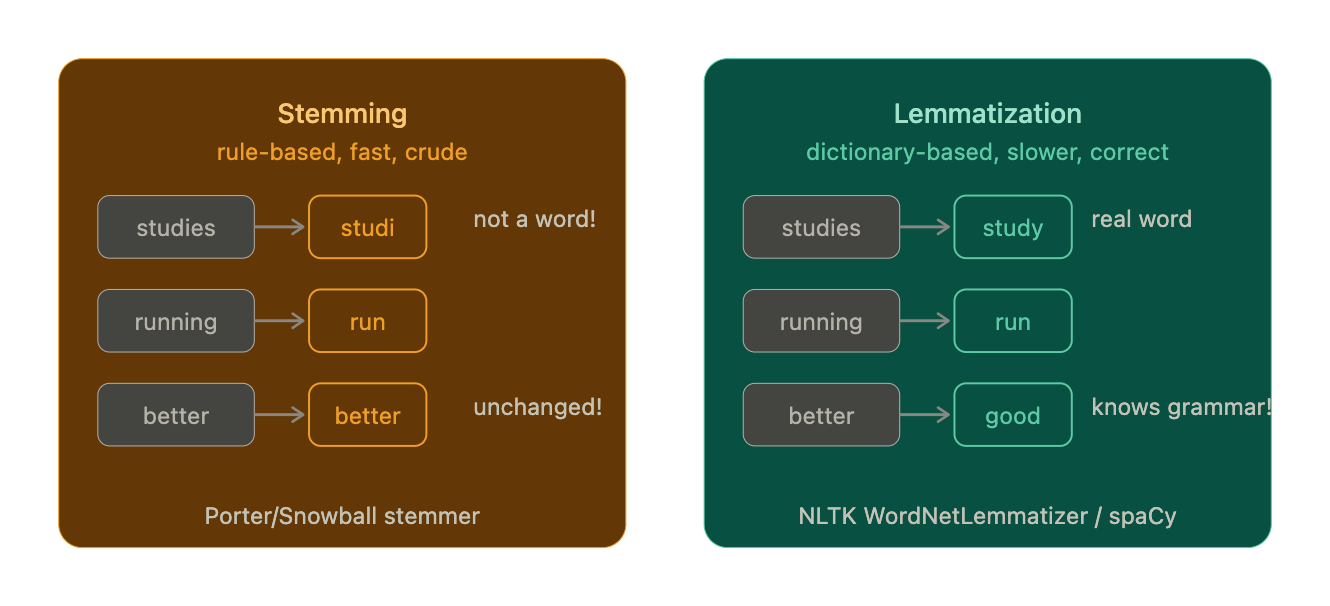

"better" → "good" is the killer example — only lemmatization can do that because it needs to know that "better" is the comparative form of "good". A stemmer just sees no suffix to cut and gives up.

## **Simple code**

In [19]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [20]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [28]:
text = "Running better Cats LOVED jumping over 3 tall walls!! Visit https://cats.com"


In [29]:
text = text.lower()
text

'running better cats loved jumping over 3 tall walls!! visit https://cats.com'

In [30]:
text = re.sub(r'https?://\S+', '', text)   # remove URLs
text = re.sub(r'\d+', '', text)             # remove numbers
text = re.sub(r'[^a-z\s]', '', text)        # remove punctuation
text = text.strip()
text

'running better cats loved jumping over  tall walls visit'

In [31]:
tokens = text.split()
tokens

['running',
 'better',
 'cats',
 'loved',
 'jumping',
 'over',
 'tall',
 'walls',
 'visit']

In [32]:
stop_words = set(stopwords.words('english'))
tokens = [t for t in tokens if t not in stop_words]
tokens

['running', 'better', 'cats', 'loved', 'jumping', 'tall', 'walls', 'visit']

In [33]:
stemmer = PorterStemmer()
stemmed = [stemmer.stem(t) for t in tokens]
print(stemmed)

['run', 'better', 'cat', 'love', 'jump', 'tall', 'wall', 'visit']


In [34]:
lemmatizer = WordNetLemmatizer()
lemmas = [lemmatizer.lemmatize(t, pos='v') for t in tokens]  # pos='v' for verbs
print(lemmas)

['run', 'better', 'cat', 'love', 'jump', 'tall', 'wall', 'visit']
